# UAH First Master Dataset

## Objective

This notebook creates the first unified dataset by synchronizing
accelerometer and GPS data using timestamps.

Goals

- Load accelerometer data
- Load GPS data
- Synchronize timestamps
- Create the first master dataframe
- Validate merged data

No feature engineering is performed.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
dataset_path="/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/raw/UAH-DRIVESET-v1"

driver="D1"

trip="20151110175712-16km-D1-NORMAL1-SECONDARY"

trip_path=os.path.join(
    dataset_path,
    driver,
    trip
)

In [3]:
acc_path=os.path.join(trip_path,"RAW_ACCELEROMETERS.txt")

gps_path=os.path.join(trip_path,"RAW_GPS.txt")

In [4]:
acc_columns=[
    "timestamp",
    "active",
    "acc_x",
    "acc_y",
    "acc_z",
    "acc_x_kf",
    "acc_y_kf",
    "acc_z_kf",
    "roll",
    "pitch",
    "yaw"
]

acc_df=pd.read_csv(
    acc_path,
    sep=r"\s+",
    header=None,
    names=acc_columns
)

In [5]:
gps_columns=[
    "timestamp",
    "speed",
    "latitude",
    "longitude",
    "altitude",
    "gps_quality",
    "satellites",
    "heading",
    "extra_1",
    "extra_2",
    "extra_3",
    "extra_4"
]

gps_df=pd.read_csv(
    gps_path,
    sep=r"\s+",
    header=None,
    names=gps_columns
)

In [6]:
acc_df=acc_df.sort_values("timestamp")

gps_df=gps_df.sort_values("timestamp")

In [7]:
master_df=pd.merge_asof(

    acc_df,

    gps_df,

    on="timestamp",

    direction="nearest"

)

In [8]:
master_df.head()

,timestamp,active,acc_x,acc_y,acc_z,acc_x_kf,acc_y_kf,acc_z_kf,roll,pitch,...,latitude,longitude,altitude,gps_quality,satellites,heading,extra_1,extra_2,extra_3,extra_4
0,6.94,1,0.017,-0.011,0.018,-0.005,0.008,0.018,-1.523,0.015,...,40.512787,-3.404477,612.7,4,5,331.9,0.0,0,0,0
1,7.03,1,0.046,0.007,0.019,0.016,-0.002,0.018,-1.522,0.012,...,40.512787,-3.404477,612.7,4,5,331.9,0.0,0,0,0
2,7.14,1,0.052,-0.016,0.027,0.037,-0.005,0.018,-1.520,0.014,...,40.512787,-3.404477,612.7,4,5,331.9,0.0,0,0,0
3,7.24,1,0.015,-0.016,0.026,0.038,-0.009,0.024,-1.523,0.014,...,40.512787,-3.404477,612.7,4,5,331.9,0.0,0,0,0
4,7.34,1,-0.014,-0.017,0.040,0.012,-0.016,0.032,-1.525,0.012,...,40.512787,-3.404477,612.7,4,5,331.9,0.0,0,0,0


In [9]:
master_df.shape

(6170, 22)

In [10]:
master_df.isnull().sum()

,0
timestamp,0
active,0
acc_x,0
acc_y,0
acc_z,0
acc_x_kf,0
acc_y_kf,0
acc_z_kf,0
roll,0
pitch,0


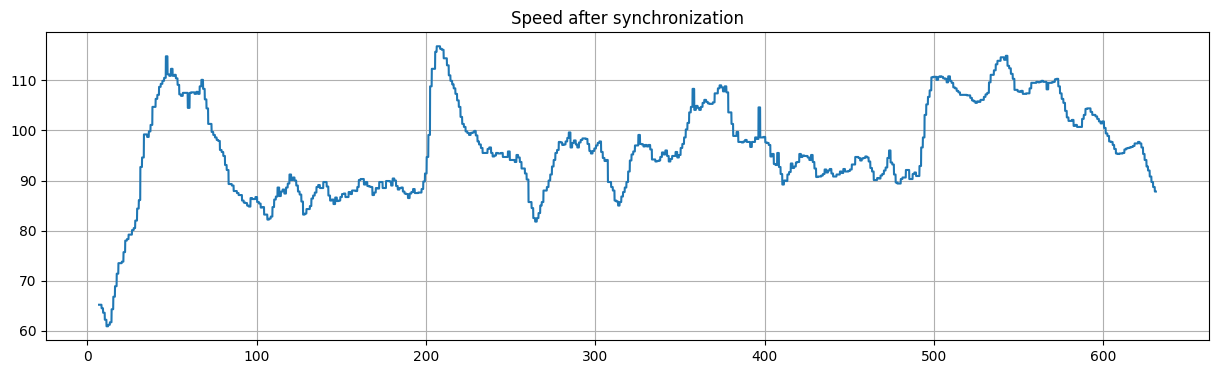

In [11]:
plt.figure(figsize=(15,4))

plt.plot(master_df["timestamp"],master_df["speed"])

plt.title("Speed after synchronization")

plt.grid(True)

plt.show()

In [12]:
output_path = "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed"

os.makedirs(output_path, exist_ok=True)

master_df.to_csv(
    os.path.join(output_path, "master_dataset_D1_NORMAL1.csv"),
    index=False
)

print("Master dataset saved successfully.")

Master dataset saved successfully.
